In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV

In [ ]:
df = pd.read_csv("/content/drive/My Drive/MSA 8150 Final/data.csv")



In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64


In [ ]:
df = df[df['GrLivArea'] < 4000]

In [ ]:
#DATA SPLITTING
X = df.drop(['SalePrice', 'Id'], axis=1)
y = df['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

#if houses do not have these features, fill in "none" instead of NA
df['PoolQC'] = df['PoolQC'].fillna('None')
df['MiscFeature'] = df['MiscFeature'].fillna('None')
df['Alley'] = df['Alley'].fillna('None')
df['BsmtCond'] = df['BsmtCond'].fillna('None')
df['BsmtQual'] = df['BsmtQual'].fillna('None')
df['BsmtFinType1'] = df['BsmtFinType1'].fillna('None')
df['BsmtFinType2'] = df['BsmtFinType2'].fillna('None')
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')
df['GarageType'] = df['GarageType'].fillna('GarageType')
df['GarageFinish'] = df['GarageFinish'].fillna('None')
df['GarageQual'] = df['GarageQual'].fillna('None')
df['GarageCond'] = df['GarageCond'].fillna('None')
df['Fence'] = df['Fence'].fillna('None')

In [ ]:
#mapping quality to numbers
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond','PoolQC']

for col in qual_cols:
    X_train[col] = X_train[col].map(qual_map).fillna(0)
    X_val[col] = X_val[col].map(qual_map).fillna(0)

In [ ]:
exposure_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
fin_type_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}

# Applying the map
X_train['BsmtExposure'] = X_train['BsmtExposure'].map(exposure_map).fillna(0)
X_val['BsmtExposure'] = X_val['BsmtExposure'].map(exposure_map).fillna(0)

X_train['BsmtFinType1'] = X_train['BsmtFinType1'].map(fin_type_map).fillna(0)
X_val['BsmtFinType1'] = X_val['BsmtFinType1'].map(fin_type_map).fillna(0)

X_train['BsmtFinType2'] = X_train['BsmtFinType2'].map(fin_type_map).fillna(0)
X_val['BsmtFinType2'] = X_val['BsmtFinType2'].map(fin_type_map).fillna(0)

In [ ]:
#One hot encoding


# NOMINAL COLUMNS
nominal_cols = [
    'MSSubClass','MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig',
    'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'Foundation', 'Heating', 'CentralAir', 'GarageType', 'SaleType', 'SaleCondition','Utilities',
    'LandSlope','Electrical','Functional','GarageFinish', 'PavedDrive', 'Fence','MiscFeature'
]

# 2. INITIALIZE ONEHOTENCODER
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 3. FIT AND TRANSFORM THE TRAINING DATA
ohe_train_array = ohe.fit_transform(X_train[nominal_cols])

# Convert back to a DataFrame
ohe_train_df = pd.DataFrame(
    ohe_train_array,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_train.index
)

# 4. TRANSFORM THE VALIDATION DATA

ohe_val_array = ohe.transform(X_val[nominal_cols])
ohe_val_df = pd.DataFrame(
    ohe_val_array,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_val.index
)

# 5. COMBINE BACK WITH ORIGINAL DATA

X_train_final = X_train.drop(nominal_cols, axis=1).join(ohe_train_df)
X_val_final = X_val.drop(nominal_cols, axis=1).join(ohe_val_df)

print(f"Total features after One-Hot Encoding: {X_train_final.shape[1]}")

Total features after One-Hot Encoding: 259


In [ ]:
numeric_cols = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
    'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal','BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', ]

In [ ]:
#Filling nan in numeric columns with 0

zero_imputer = SimpleImputer(strategy='constant', fill_value=0)

X_train_final[numeric_cols] = zero_imputer.fit_transform(X_train_final[numeric_cols])

X_val_final[numeric_cols] = zero_imputer.transform(X_val_final[numeric_cols])



In [ ]:
# 2. FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final[numeric_cols] = scaler.fit_transform(X_train_final[numeric_cols])

X_val_final[numeric_cols] = scaler.transform(X_val_final[numeric_cols])

In [ ]:
X_train_final = X_train_final.fillna(0)
X_val_final = X_val_final.fillna(0)

###Lasso

In [ ]:
# LASSO
#1. FIND THE BEST ALPHA using Cross-Validation
lasso_cv = LassoCV(alphas=None, cv=5, max_iter=10000)
lasso_cv.fit(X_train_final, y_train)

print(f"Best Alpha found: {lasso_cv.alpha_}")


y_pred = lasso_cv.predict(X_val_final)


mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Best Alpha found: 9474.762469715384
Root Mean Squared Error (RMSE): $44,296.98
R-squared (R2) Score: 0.7442


###Ridge

In [ ]:

ridge_alphas = np.logspace(-2, 3, 100)
ridge_model = RidgeCV(alphas=ridge_alphas, cv=5)

ridge_model.fit(X_train_final, y_train)

print(f"Best Ridge Alpha: {ridge_model.alpha_:.4f}")


y_pred_ridge = ridge_model.predict(X_val_final)

# 4. EVALUATE
rmse_ridge_model = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
r2_ridge_model = r2_score(y_val, y_pred_ridge)

print(f"Ridge RMSE: ${rmse_ridge_model:,.2f}")
print(f"Ridge R-squared: {r2_ridge_model:.4f}")


Best Ridge Alpha: 19.1791
Ridge RMSE: $22,800.22
Ridge R-squared: 0.9010


#Log Transformation

In [ ]:
y_log = np.log1p(df['SalePrice'])
X = df.drop(['SalePrice', 'Id'], axis=1)
X_train, X_val, y_train_log, y_val_log = train_test_split(X, y_log, test_size=0.2, random_state=42)



#if houses do not have these features, fill in "none" instead of NA
df['PoolQC'] = df['PoolQC'].fillna('None')
df['MiscFeature'] = df['MiscFeature'].fillna('None')
df['Alley'] = df['Alley'].fillna('None')
df['BsmtCond'] = df['BsmtCond'].fillna('None')
df['BsmtQual'] = df['BsmtQual'].fillna('None')
df['BsmtFinType1'] = df['BsmtFinType1'].fillna('None')
df['BsmtFinType2'] = df['BsmtFinType2'].fillna('None')
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')
df['GarageType'] = df['GarageType'].fillna('GarageType')
df['GarageFinish'] = df['GarageFinish'].fillna('None')
df['GarageQual'] = df['GarageQual'].fillna('None')
df['GarageCond'] = df['GarageCond'].fillna('None')
df['Fence'] = df['Fence'].fillna('None')



In [ ]:
#mapping quality to numbers
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond','PoolQC']

for col in qual_cols:
    X_train[col] = X_train[col].map(qual_map).fillna(0)
    X_val[col] = X_val[col].map(qual_map).fillna(0)

In [ ]:
exposure_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
fin_type_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}

# Applying the map
X_train['BsmtExposure'] = X_train['BsmtExposure'].map(exposure_map).fillna(0)
X_val['BsmtExposure'] = X_val['BsmtExposure'].map(exposure_map).fillna(0)

X_train['BsmtFinType1'] = X_train['BsmtFinType1'].map(fin_type_map).fillna(0)
X_val['BsmtFinType1'] = X_val['BsmtFinType1'].map(fin_type_map).fillna(0)

X_train['BsmtFinType2'] = X_train['BsmtFinType2'].map(fin_type_map).fillna(0)
X_val['BsmtFinType2'] = X_val['BsmtFinType2'].map(fin_type_map).fillna(0)

In [ ]:
#One hot encoding


# NOMINAL COLUMNS
nominal_cols = [
    'MSSubClass','MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig',
    'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'Foundation', 'Heating', 'CentralAir', 'GarageType', 'SaleType', 'SaleCondition','Utilities',
    'LandSlope','Electrical','Functional','GarageFinish', 'PavedDrive', 'Fence','MiscFeature'
]

# 2. INITIALIZE ONEHOTENCODER
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 3. FIT AND TRANSFORM THE TRAINING DATA
ohe_train_array = ohe.fit_transform(X_train[nominal_cols])

# Convert back to a DataFrame
ohe_train_df = pd.DataFrame(
    ohe_train_array,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_train.index
)

# 4. TRANSFORM THE VALIDATION DATA

ohe_val_array = ohe.transform(X_val[nominal_cols])
ohe_val_df = pd.DataFrame(
    ohe_val_array,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_val.index
)

# 5. COMBINE BACK WITH ORIGINAL DATA

X_train_final = X_train.drop(nominal_cols, axis=1).join(ohe_train_df)
X_val_final = X_val.drop(nominal_cols, axis=1).join(ohe_val_df)

print(f"Total features after One-Hot Encoding: {X_train_final.shape[1]}")

Total features after One-Hot Encoding: 257


In [ ]:
numeric_cols = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
    'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal','BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', ]

In [ ]:
#Filling nan in numeric columns with 0

zero_imputer = SimpleImputer(strategy='constant', fill_value=0)

X_train_final[numeric_cols] = zero_imputer.fit_transform(X_train_final[numeric_cols])

X_val_final[numeric_cols] = zero_imputer.transform(X_val_final[numeric_cols])

In [ ]:
# 2. FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final[numeric_cols] = scaler.fit_transform(X_train_final[numeric_cols])

X_val_final[numeric_cols] = scaler.transform(X_val_final[numeric_cols])

In [ ]:
X_train_final = X_train_final.fillna(0)
X_val_final = X_val_final.fillna(0)

###LASSO

In [ ]:
lasso_log = LassoCV(cv=5, max_iter=10000)
lasso_log.fit(X_train_final, y_train_log)

y_pred_log = lasso_log.predict(X_val_final)

# Reverting log to get real dollar values
y_pred_dollars = np.expm1(y_pred_log)
y_val_dollars = np.expm1(y_val_log)

r2 = r2_score(y_val_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_val_dollars, y_pred_dollars))

print(f"Best Alpha: {lasso_log.alpha_:.4f}")
print(f"R-squared Score (Log): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

Best Alpha: 0.0657
R-squared Score (Log): 0.8011
Root Mean Squared Error (RMSE): $31,780.97


###Ridge

In [ ]:
# 1. FIND THE BEST ALPHA FOR RIDGE
ridge_alphas = np.logspace(-2, 3, 100)
ridge_cv = RidgeCV(alphas=ridge_alphas, cv=5)

ridge_cv.fit(X_train_final, y_train_log)

print(f"Best Ridge Alpha found: {ridge_cv.alpha_:.4f}")


y_pred_ridge_log = ridge_cv.predict(X_val_final)

# 3. REVERT LOG TO DOLLARS
y_pred_ridge_dollars = np.expm1(y_pred_ridge_log)
y_val_dollars = np.expm1(y_val_log)


rmse_ridge = np.sqrt(mean_squared_error(y_val_dollars, y_pred_ridge_dollars))
r2_ridge = r2_score(y_val_log, y_pred_ridge_log)

print(f"Ridge RMSE: ${rmse_ridge:,.2f}")
print(f"Ridge R-squared (R2): {r2_ridge:.4f}")

print(f"\n--- Comparison ---")
print(f"Lasso R2: {r2:.4f} | Ridge R2: {r2_ridge:.4f}")
print(f"Lasso RMSE: ${rmse:,.2f} | Ridge RMSE: ${rmse_ridge:,.2f}")

Best Ridge Alpha found: 24.2013
Ridge RMSE: $19,742.10
Ridge R-squared (R2): 0.9028

--- Comparison ---
Lasso R2: 0.8011 | Ridge R2: 0.9028
Lasso RMSE: $31,780.97 | Ridge RMSE: $19,742.10


###Feature Importance

Ridge utilized all 257 features to achieve the 0.90 R-squared score.


/tmp/ipykernel_31699/93524061.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='vlag')


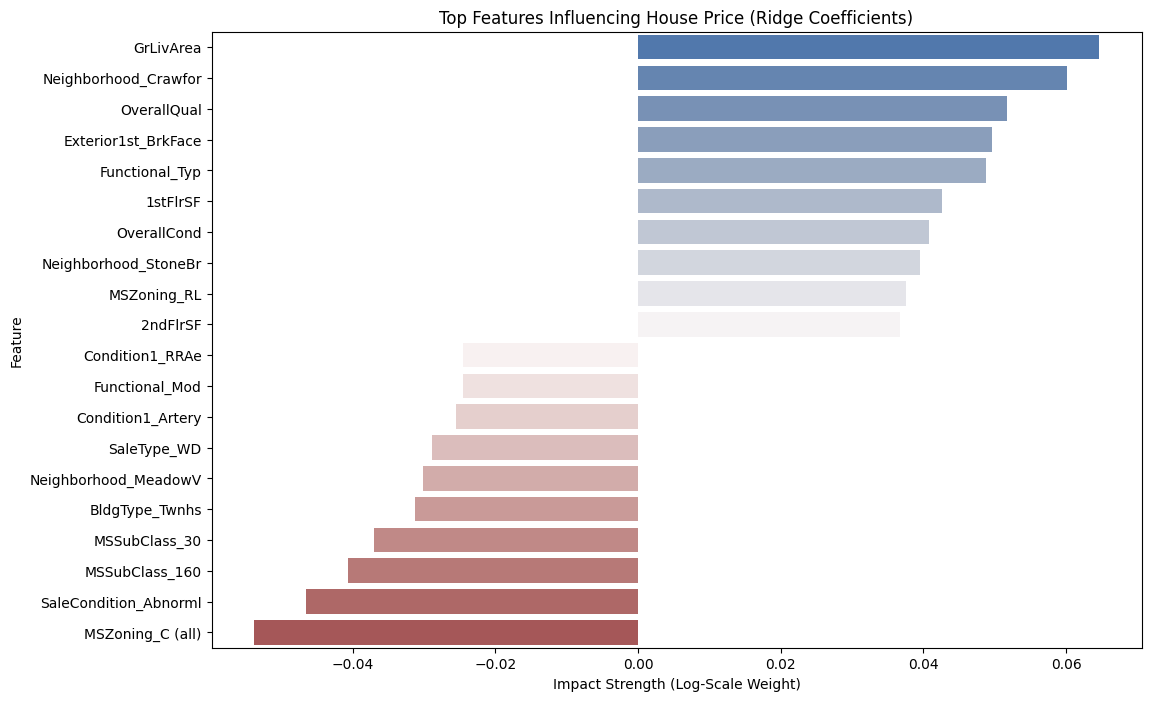


--- Key Value Drivers (Percentage Impact) ---
1 StdDev increase in GrLivArea: Increases value by approx. 6.68%
1 StdDev increase in Neighborhood_Crawfor: Increases value by approx. 6.20%
1 StdDev increase in OverallQual: Increases value by approx. 5.31%
1 StdDev increase in Exterior1st_BrkFace: Increases value by approx. 5.08%
1 StdDev increase in Functional_Typ: Increases value by approx. 5.00%
1 StdDev increase in BldgType_Twnhs: Decreases value by approx. 3.07%
1 StdDev increase in MSSubClass_30: Decreases value by approx. 3.63%
1 StdDev increase in MSSubClass_160: Decreases value by approx. 3.99%
1 StdDev increase in SaleCondition_Abnorml: Decreases value by approx. 4.54%
1 StdDev increase in MSZoning_C (all): Decreases value by approx. 5.24%


In [ ]:

# 1. EXTRACT RIDGE COEFFICIENTS

coef_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Coefficient': ridge_cv.coef_
})

# 2. SORT FEATURES

active_features = coef_df.sort_values(by='Coefficient', ascending=False)

print(f"Ridge utilized all {len(active_features)} features to achieve the 0.90 R-squared score.")

# 3. VISUALIZE THE TOP 10 POSITIVE & TOP 10 NEGATIVE
top_features = pd.concat([active_features.head(10), active_features.tail(10)])

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='vlag')
plt.title('Top Features Influencing House Price (Ridge Coefficients)')
plt.xlabel('Impact Strength (Log-Scale Weight)')
plt.show()

# 4. INTERPRET THE VALUE (The "Renovation" Insight)
# Note: Because we used log-transformation, coefficients represent % change.
print("\n--- Key Value Drivers (Percentage Impact) ---")
for index, row in active_features.head(5).iterrows():
    # Calculation: (np.exp(coef) - 1) * 100 gives the % increase
    pct_change = (np.exp(row['Coefficient']) - 1) * 100
    print(f"1 StdDev increase in {row['Feature']}: Increases value by approx. {pct_change:.2f}%")

for index, row in active_features.tail(5).iterrows():
    pct_change = (1 - np.exp(row['Coefficient'])) * 100
    print(f"1 StdDev increase in {row['Feature']}: Decreases value by approx. {pct_change:.2f}%")

#EDA

In [ ]:
print(f"Dataset Shape: {df.shape}")
print(df.info())

Dataset Shape: (1456, 81)
<class 'pandas.core.frame.DataFrame'>
Index: 1456 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1456 non-null   int64  
 1   MSSubClass     1456 non-null   int64  
 2   MSZoning       1456 non-null   object 
 3   LotFrontage    1197 non-null   float64
 4   LotArea        1456 non-null   int64  
 5   Street         1456 non-null   object 
 6   Alley          1456 non-null   object 
 7   LotShape       1456 non-null   object 
 8   LandContour    1456 non-null   object 
 9   Utilities      1456 non-null   object 
 10  LotConfig      1456 non-null   object 
 11  LandSlope      1456 non-null   object 
 12  Neighborhood   1456 non-null   object 
 13  Condition1     1456 non-null   object 
 14  Condition2     1456 non-null   object 
 15  BldgType       1456 non-null   object 
 16  HouseStyle     1456 non-null   object 
 17  OverallQual    1456 non-null   

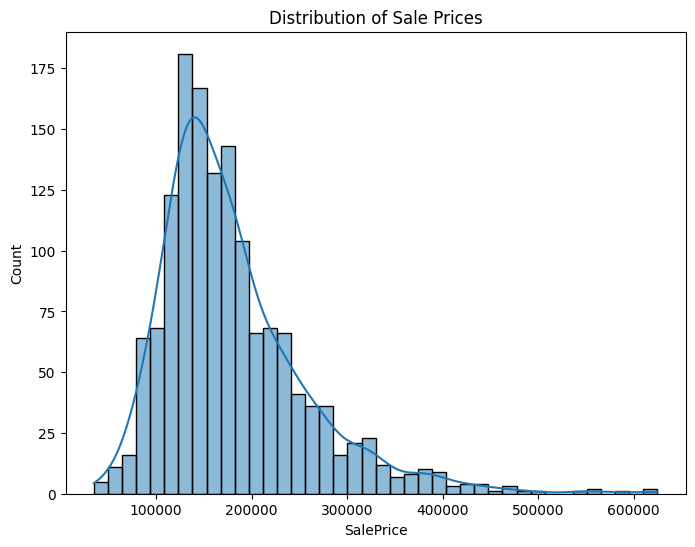

In [ ]:
# Visualizing Sales Price
plt.figure(figsize=(8, 6))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of Sale Prices')
plt.show()

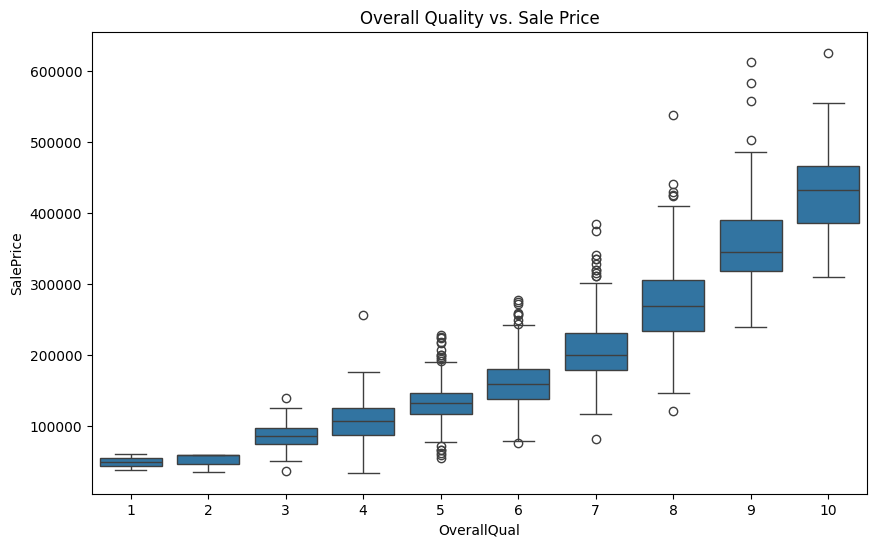

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('Overall Quality vs. Sale Price')
plt.show()

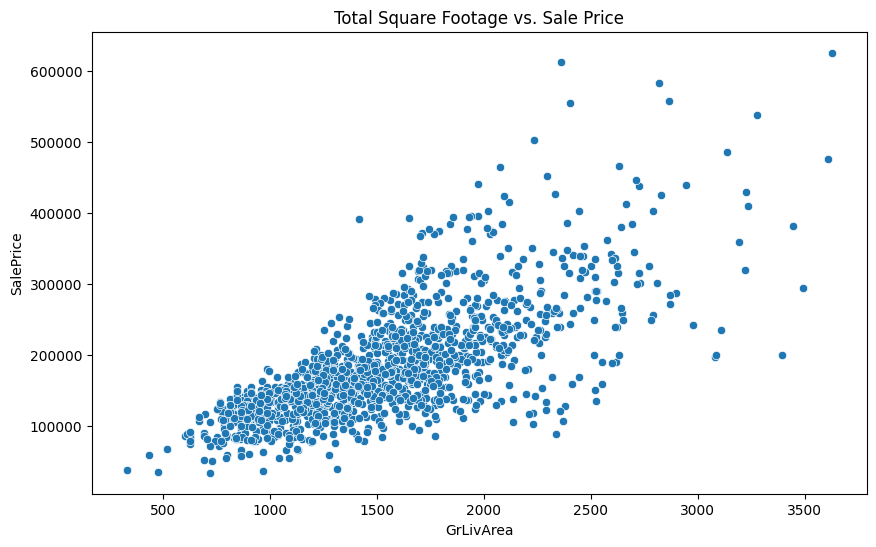

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('Total Square Footage vs. Sale Price')
plt.show()

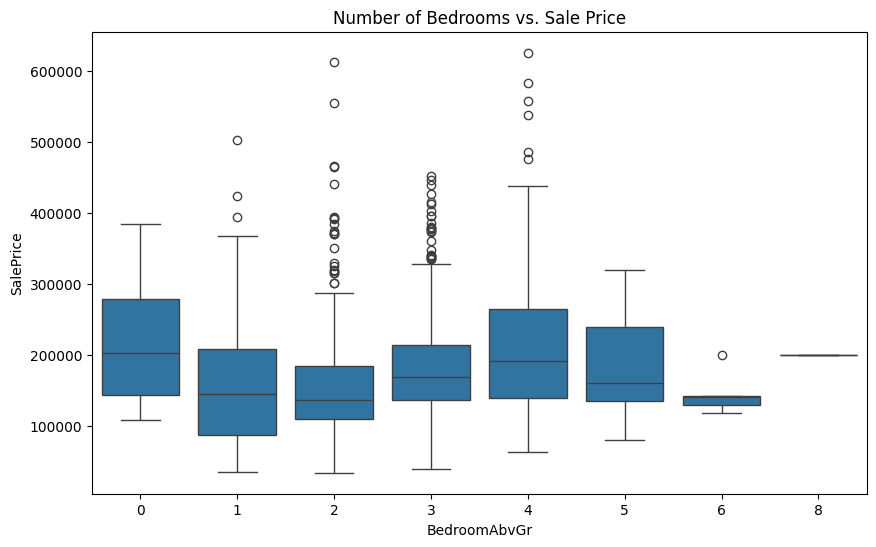

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='BedroomAbvGr', y='SalePrice', data=df)
plt.title('Number of Bedrooms vs. Sale Price')
plt.show()

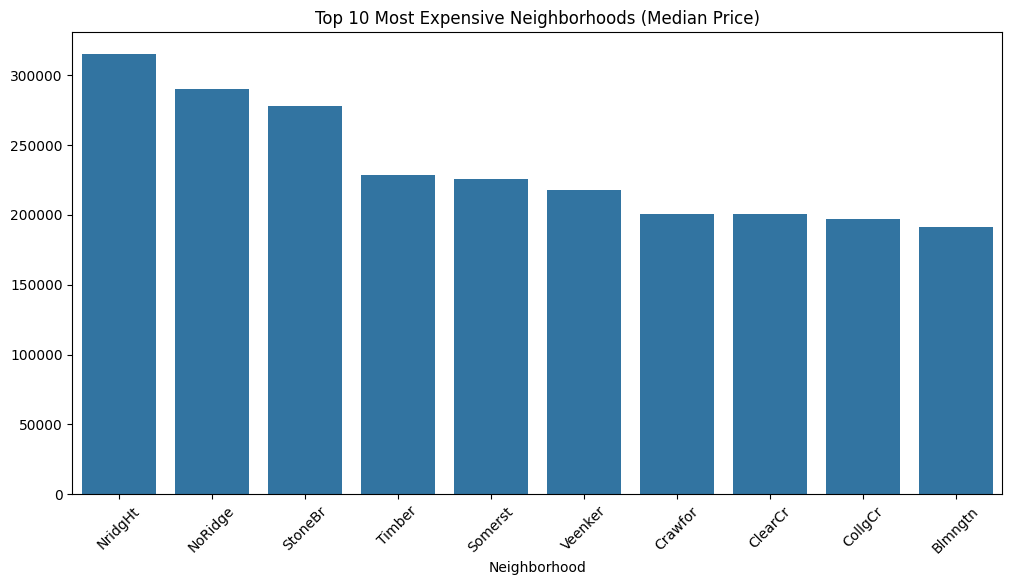

In [ ]:
plt.figure(figsize=(12, 6))
top_10_hoods = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).head(10)
sns.barplot(x=top_10_hoods.index, y=top_10_hoods.values)
plt.title('Top 10 Most Expensive Neighborhoods (Median Price)')
plt.xticks(rotation=45)
plt.show()

Outlier Summary Count
EnclosedPorch    208
BsmtFinSF2       167
ScreenPorch      116
MasVnrArea        95
LotFrontage       85
BsmtHalfBath      81
OpenPorchSF       75
KitchenAbvGr      68
LotArea           66
TotalBsmtSF       59
MiscVal           52
BedroomAbvGr      35
WoodDeckSF        32
TotRmsAbvGrd      28
BsmtUnfSF         28
GrLivArea         27
LowQualFinSF      26
3SsnPorch         24
GarageArea        20
1stFlrSF          16
BsmtFinSF1         5
PoolArea           5
GarageCars         5
Fireplaces         4
BsmtFullBath       1
dtype: int64


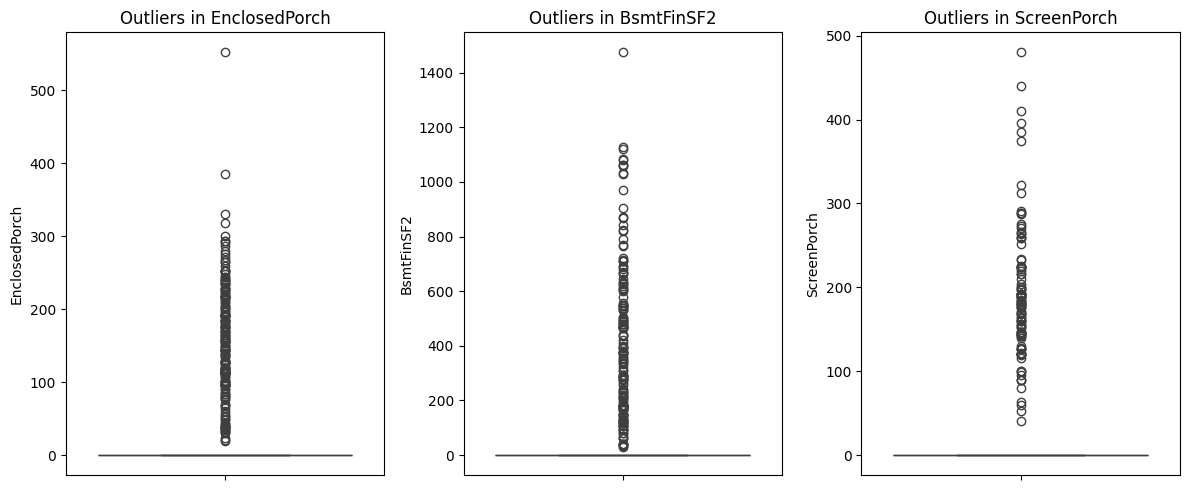

In [ ]:
#NUMBER OF OUTLIERS
numeric_df = df[numeric_cols]

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = ((numeric_df < lower_bound) | (numeric_df > upper_bound)).sum()

outlier_summary = outliers_count[outliers_count > 0].sort_values(ascending=False)

print("Outlier Summary Count")
print(outlier_summary)


top_outlier_cols = outlier_summary.head(3).index.tolist()
plt.figure(figsize=(12, 5))
for i, col in enumerate(top_outlier_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Outliers in {col}")
plt.tight_layout()
plt.show()